# IGVF Perturb-seq Analysis

CRISPRi perturb-seq in HUES8 definitive endoderm (Huangfu lab).

**Data sources:**
- `inference_mudata.h5mu`: expression + guide matrices, cell metadata
- Calibrated result TSVs (`muddy_penguin_calibrated_*`): cis, trans, direct target results with empirical p-values
- GWAS catalog + OpenTargets for disease overlay

## 0. Setup and thresholds

In [2]:
import os
import numpy as np
import pandas as pd
import mudata as md
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

#md.set_options(pull_on_update=False)
os.makedirs("cache", exist_ok=True)

# === THRESHOLDS ===
PVAL_ADJ_CUTOFF = 0.05
LOG2FC_CIS_MIN = 0.2
LOG2FC_TRANS_MIN = 1.0
N_TOP_REGULATORS = 20
GWAS_WINDOW = 50_000  # bp around features for GWAS overlap

# === PATHS ===
#MUDATA_PATH = "./data/inference_mudata.h5mu"
MUDATA_PATH = "/hpc/group/gersbachlab/seg95/CRISPR_Pipeline/helen_output_poolabcd_prod_v10/inference_mudata.h5mu"
#CAL_PREFIX = "data/Huangfu_HUES8-definitive-endoderm-differentiation_TF-Perturb-seq_muddy_penguin_calibrated_"
CAL_PREFIX = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq/calibrated_outs/Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq_sara_synapse_syn74842722_calibrated_"
#GWAS_PATH = "data/gwas-catalog-download-associations-v1.0-full.tsv"
GWAS_PATH = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/ref/gwas-catalog-download-associations-v1.0-full.tsv"

OT_ASSOC_PATH = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq/association_by_datasource_direct/"
OT_DISEASE_PATH = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq/disease/disease.parquet"

## 1. Load MuData (expression + guide matrices)

In [3]:
mdata = md.read_h5mu(MUDATA_PATH)
print(mdata)

gene_var = mdata.mod["gene"].var
guide_var = mdata.mod["guide"].var

# Ensembl ID -> gene symbol mapping
id_to_symbol = gene_var["symbol"].to_dict()
id_to_symbol.update(
    guide_var[["intended_target_name", "gene_name"]]
    .drop_duplicates()
    .set_index("intended_target_name")["gene_name"]
    .to_dict()
)

MuData object with n_obs × n_vars = 1053820 × 25289
  obs:	'batch'
  uns:	'cis_per_element_results', 'cis_per_guide_results', 'trans_per_element_results', 'trans_per_guide_results'
  2 modalities
    gene:	1053820 x 11138
      obs:	'batch', 'batch_number', 'n_counts', 'log1p_n_genes_by_counts', 'total_gene_umis', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'percent_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'num_expressed_genes'
      var:	'symbol', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'gene_chr', 'gene_start', 'gene_end'
    guide:	1053820 x 14151
      obs:	'batch', 'num_expressed_guides', 'total_guide_umis'
      var:	'guide_id', 'spacer', 'targeting', 'type', 'guide_chr', 'guide_start', 'guide_end', 's

## 2. Guide library overview

In [4]:
print(guide_var["type"].value_counts())
print(f"\nUnique intended targets: {guide_var['intended_target_name'].nunique()}")

assignments = mdata.mod["guide"].layers["guide_assignment"]
guides_per_cell = np.array(assignments.sum(axis=1)).flatten()
cells_assigned = (guides_per_cell > 0).sum()

print(f"\nCells with guide: {cells_assigned} / {assignments.shape[0]} ({cells_assigned/assignments.shape[0]:.1%})")
print(f"Guides/cell: median={np.median(guides_per_cell):.0f}, mean={np.mean(guides_per_cell):.2f}")

targeting = guide_var[guide_var["targeting"] == True]
gpt = targeting.groupby("intended_target_name", observed=True).size()
print(f"Guides/target: median={gpt.median():.0f}, mean={gpt.mean():.1f}")

print(f"\nBatches:\n{mdata.obs['batch'].value_counts()}")

targeting           12934
non-targeting         600
negative control      598
positive control       19
Name: type, dtype: int64

Unique intended targets: 2161

Cells with guide: 840841 / 1053820 (79.8%)
Guides/cell: median=2, mean=2.05
Guides/target: median=6, mean=6.6

Batches:
B8_S16    28571
C3_S19    27906
D2_S26    27544
C8_S24    27301
C4_S20    27199
C2_S18    26955
D4_S28    26341
B2_S10    26315
D6_S30    26106
D8_S32    26036
C7_S23    25989
C5_S21    25654
D5_S29    25511
A8_S8     25292
A6_S6     25239
D3_S27    25171
B4_S12    25131
A7_S7     24713
C6_S22    24680
D7_S31    24604
B5_S13    24292
E6_S38    24073
E3_S35    23934
B3_S11    23923
A3_S3     23901
A2_S2     23641
E4_S36    23534
A4_S4     23386
E5_S37    23332
B6_S14    22810
E8_S40    22687
B7_S15    22610
A1_S1     22474
E1_S33    22425
E2_S34    22304
D1_S25    21851
E7_S39    21704
A5_S5     20980
B1_S9     20784
F4_S44    15149
F6_S46    15129
F7_S47    15069
F5_S45    14709
F3_S43    11979
F1_S41    11148

## 3. Load calibrated inference results

These TSVs contain empirically calibrated p-values (already adjusted for multiple testing).
- **direct_target**: self-knockdown efficiency per element
- **cis**: effects on nearby genes
- **trans**: genome-wide distal effects

In [18]:
direct = pd.read_csv(CAL_PREFIX + "direct_target_results.tsv", sep="\t")
cis = pd.read_csv(CAL_PREFIX + "cis_results.tsv", sep="\t")
trans = pd.read_csv(CAL_PREFIX + "trans_results.tsv", sep="\t")

print(f"Direct targets: {direct.shape}")
print(f"Cis: {cis.shape}")
print(f"Trans: {trans.shape}")
print(f"\nColumns: {direct.columns.tolist()}")

/tmp/ipykernel_1496402/2468841602.py:3: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  trans = pd.read_csv(CAL_PREFIX + "trans_results.tsv", sep="\t")


Direct targets: (1222, 13)
Cis: (4798, 13)
Trans: (11098802, 13)

Columns: ['element_id', 'element_symbol', 'element_label', 'tested_gene_id', 'tested_gene_symbol', 'n_cells', 'log2fc', 'log2fc_se', 'is_cis', 'is_direct_target', 'posterior_pval', 'empirical_pval', 'empirical_pval_adj']


## 4. Direct target knockdown efficiency

In [19]:
direct_sig = direct[
    (direct["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
    & (direct["log2fc"].abs() > LOG2FC_CIS_MIN)
].copy()

print(f"Significant direct targets: {len(direct_sig)} / {len(direct)}")
print(f"\nTop knockdowns:")
print(
    direct_sig.sort_values("empirical_pval_adj")
    .head(20)[["element_symbol", "tested_gene_symbol", "log2fc", "empirical_pval_adj", "n_cells"]]
    .to_string(index=False)
)

Significant direct targets: 863 / 1222

Top knockdowns:
element_symbol tested_gene_symbol    log2fc  empirical_pval_adj  n_cells
        MALAT1             MALAT1 -3.018800        2.470667e-33      390
          TPI1               TPI1 -2.598398        3.465555e-30     1868
          SOX4               SOX4 -1.922983        1.002516e-29     4003
          EEA1               EEA1 -2.260759        2.098460e-26     1334
         ZNF91              ZNF91 -1.982073        2.701376e-26     1391
          ENO1               ENO1 -2.554135        3.437841e-26      915
          TP53               TP53 -1.921328        4.618155e-26    53017
         CXXC5              CXXC5 -1.895855        3.503575e-25     1690
           B2M                B2M -2.669130        4.621893e-25      561
         CD151              CD151 -2.519073        1.261016e-23     3920
           RB1                RB1 -1.961967        1.607174e-23     5037
       NGFRAP1               BEX3 -2.334402        2.062533e-23     

## 5. Cis results: filtering and overview

In [20]:
cis_sig = cis[
    (cis["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
    & (cis["log2fc"].abs() > LOG2FC_CIS_MIN)
].copy()

print(f"Cis significant: {len(cis_sig)} / {len(cis)}")
print(f"Unique elements: {cis_sig['element_symbol'].nunique()}")
print(f"Unique genes affected: {cis_sig['tested_gene_symbol'].nunique()}")

print("\nTop cis hits:")
print(
    cis_sig.sort_values("empirical_pval_adj")
    .head(15)[["element_symbol", "tested_gene_symbol", "log2fc", "empirical_pval_adj", "n_cells"]]
    .to_string(index=False)
)

Cis significant: 1044 / 4798
Unique elements: 888
Unique genes affected: 1000

Top cis hits:
element_symbol tested_gene_symbol    log2fc  empirical_pval_adj  n_cells
        MALAT1             MALAT1 -3.018800        2.470667e-33      390
          TPI1               TPI1 -2.598398        3.465555e-30     1868
          SOX4               SOX4 -1.922983        1.002516e-29     4003
          EEA1               EEA1 -2.260759        2.098460e-26     1334
         ZNF91              ZNF91 -1.982073        2.701376e-26     1391
          ENO1               ENO1 -2.554135        3.437841e-26      915
          TP53               TP53 -1.921328        4.618155e-26    53017
         CXXC5              CXXC5 -1.895855        3.503575e-25     1690
           RB1              ITM2B -0.560986        4.072880e-25     5037
           B2M                B2M -2.669130        4.621893e-25      561
         CD151              CD151 -2.519073        1.261016e-23     3920
           RB1                R

## 6. Trans results: filtering and caching

Trans table is ~22M rows. Filter once, cache to parquet.

In [22]:
os.makedirs("/hpc/group/gersbachlab/seg95/tf_perturb_seq/cache", exist_ok=True)
TRANS_PARQUET = f"/hpc/group/gersbachlab/seg95/tf_perturb_seq/cache/trans_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_TRANS_MIN}.parquet"

if os.path.exists(TRANS_PARQUET):
    trans_sig = pd.read_parquet(TRANS_PARQUET)
    print(f"Loaded from cache: {len(trans_sig)} rows")
else:
    print("Filtering trans results...")
    trans_sig = trans[
        (trans["empirical_pval_adj"] < PVAL_ADJ_CUTOFF)
        & (trans["log2fc"].abs() > LOG2FC_TRANS_MIN)
        # & (trans["log2fc_se"] < trans["log2fc"].abs())  # effect > SE
    ].copy()
    trans_sig.to_parquet(TRANS_PARQUET, index=False)
    print(f"Filtered and saved: {len(trans_sig)} rows")

# Only keep targeting elements (exclude non-targeting controls)
targeting_elements = set(guide_var[guide_var["targeting"] == True]["intended_target_name"].unique())
targeting_symbols = set(id_to_symbol.get(e, e) for e in targeting_elements)
trans_sig = trans_sig[trans_sig["element_symbol"].isin(targeting_symbols)].copy()

print(f"\nTrans significant: {len(trans_sig)} ({trans_sig['element_symbol'].nunique()} elements, {trans_sig['tested_gene_symbol'].nunique()} genes)")
print(trans_sig.head())

Filtering trans results...
Filtered and saved: 20717 rows

Trans significant: 20717 (1111 elements, 2847 genes)
                                    element_id element_symbol element_label  \
15598   ENSG00000004848|chrX:25015643-25015955            ARX     targeting   
20103   ENSG00000005073|chr7:27184970-27185227         HOXA11     targeting   
25953  ENSG00000005102|chr17:43661758-43661918          MEOX1     targeting   
28383    ENSG00000005339|chr16:3880184-3880693         CREBBP     targeting   
30204    ENSG00000005339|chr16:3880184-3880693         CREBBP     targeting   

        tested_gene_id tested_gene_symbol  n_cells    log2fc  log2fc_se  \
15598  ENSG00000164692             COL1A2    717.0 -1.638541   0.376431   
20103  ENSG00000120708              TGFBI    823.0 -1.901356   0.388547   
25953  ENSG00000269293        ZSCAN16-AS1    765.0 -1.055771   0.248358   
28383  ENSG00000162692              VCAM1   1832.0  1.235019   0.097036   
30204  ENSG00000091513                

## 7. P-value and effect size distributions

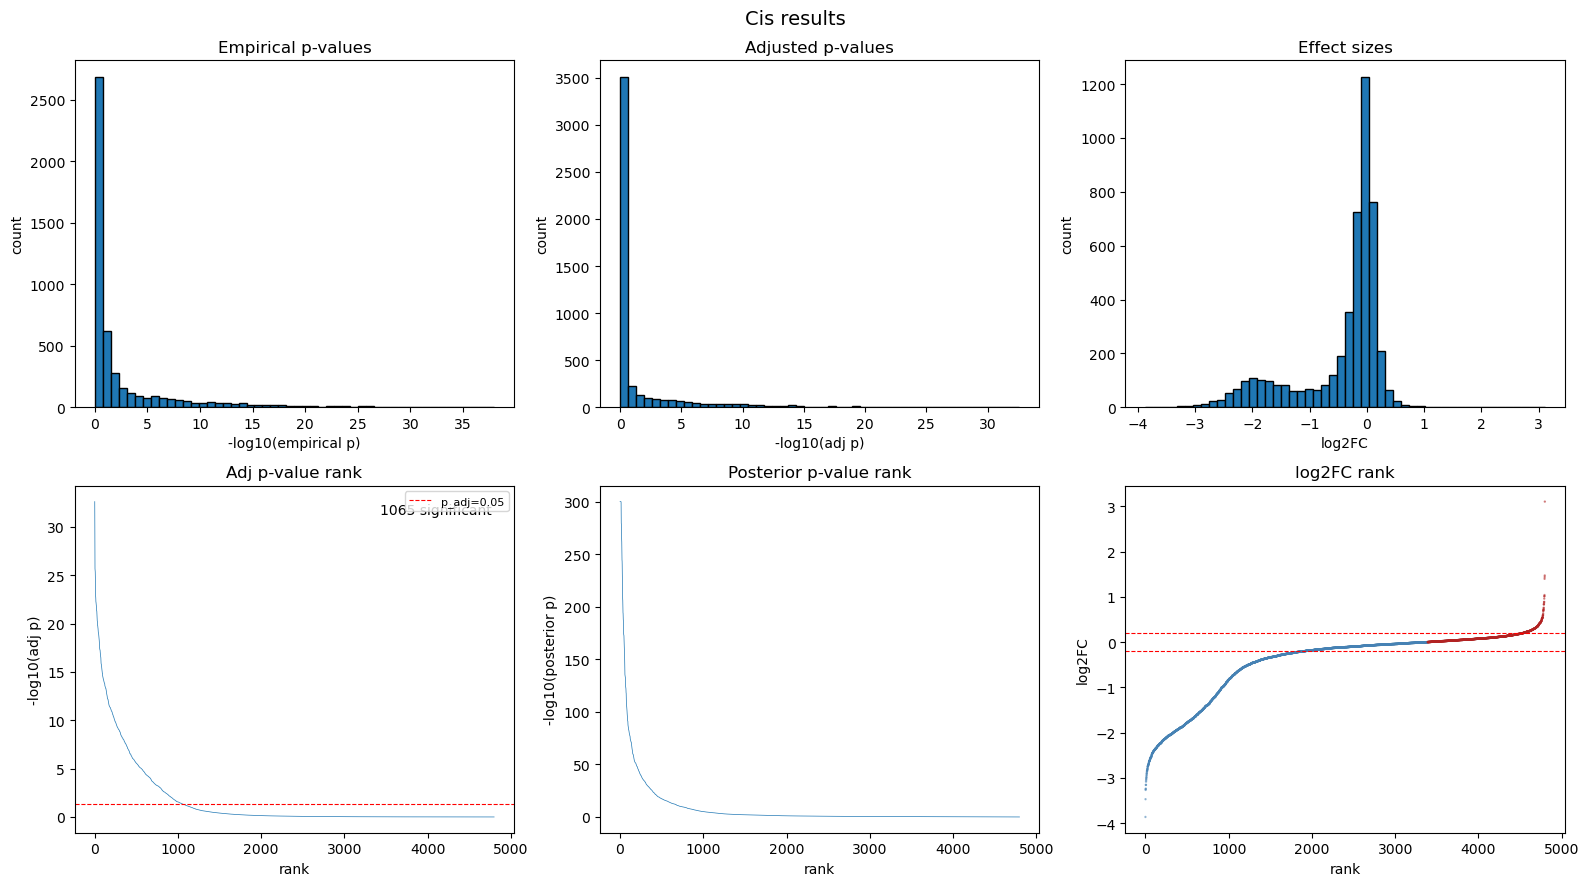

In [25]:
floor = 1e-300

# --- Cis ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Cis results", fontsize=14)

cis_finite = cis[np.isfinite(cis["log2fc"])]

axes[0, 0].hist(-np.log10(cis["empirical_pval"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 0].set(xlabel="-log10(empirical p)", ylabel="count", title="Empirical p-values")

axes[0, 1].hist(-np.log10(cis["empirical_pval_adj"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0, 1].set(xlabel="-log10(adj p)", ylabel="count", title="Adjusted p-values")

axes[0, 2].hist(cis_finite["log2fc"], bins=50, edgecolor="black")
axes[0, 2].set(xlabel="log2FC", ylabel="count", title="Effect sizes")

# Rank plots
padj_sorted = np.sort(cis["empirical_pval_adj"].values)
axes[1, 0].plot(np.arange(1, len(padj_sorted)+1), -np.log10(padj_sorted.clip(min=floor)), lw=0.5)
axes[1, 0].axhline(-np.log10(PVAL_ADJ_CUTOFF), color="r", ls="--", lw=0.8, label=f"p_adj={PVAL_ADJ_CUTOFF}")
axes[1, 0].text(0.95, 0.95, f"{(padj_sorted < PVAL_ADJ_CUTOFF).sum()} significant", transform=axes[1, 0].transAxes, ha="right", va="top")
axes[1, 0].set(xlabel="rank", ylabel="-log10(adj p)", title="Adj p-value rank")
axes[1, 0].legend(fontsize=8, loc="upper right")

post_sorted = np.sort(cis["posterior_pval"].values)
axes[1, 1].plot(np.arange(1, len(post_sorted)+1), -np.log10(post_sorted.clip(min=floor)), lw=0.5)
axes[1, 1].set(xlabel="rank", ylabel="-log10(posterior p)", title="Posterior p-value rank")

lfc_sorted = cis_finite["log2fc"].sort_values()
colors = np.where(lfc_sorted.values < 0, "steelblue", "firebrick")
axes[1, 2].scatter(np.arange(len(lfc_sorted)), lfc_sorted.values, s=0.5, c=colors, alpha=0.5)
axes[1, 2].axhline(LOG2FC_CIS_MIN, color="r", ls="--", lw=0.8)
axes[1, 2].axhline(-LOG2FC_CIS_MIN, color="r", ls="--", lw=0.8)
axes[1, 2].set(xlabel="rank", ylabel="log2FC", title="log2FC rank")

plt.tight_layout()
plt.savefig("/hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq/cis_distributions.png", dpi=150)
plt.show()

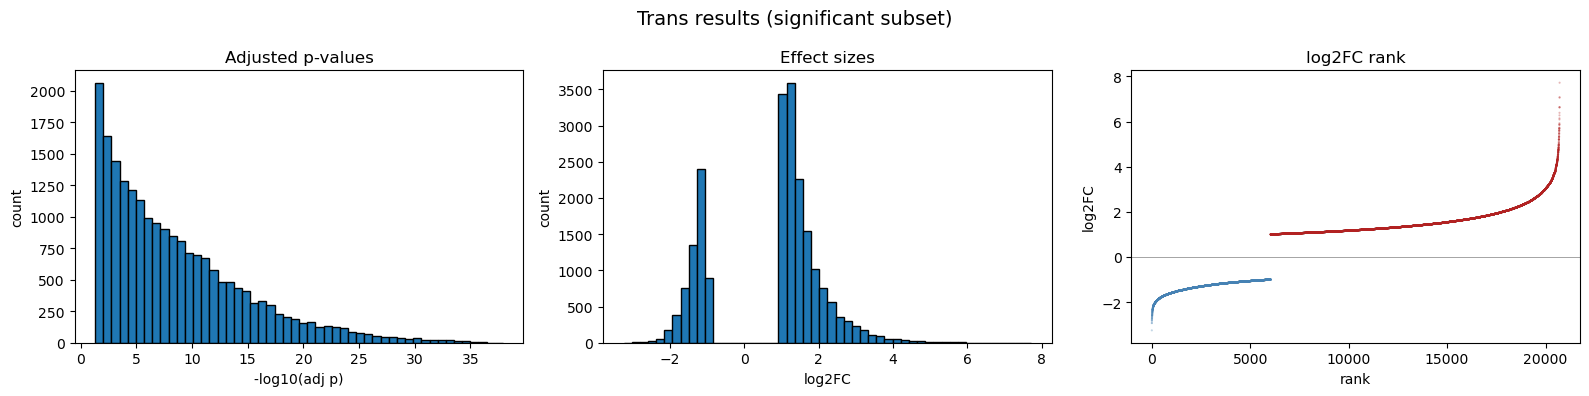

In [24]:
# --- Trans (on sig subset to avoid 22M point plots) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Trans results (significant subset)", fontsize=14)

axes[0].hist(-np.log10(trans_sig["empirical_pval_adj"].clip(lower=floor)), bins=50, edgecolor="black")
axes[0].set(xlabel="-log10(adj p)", ylabel="count", title="Adjusted p-values")

axes[1].hist(trans_sig["log2fc"], bins=50, edgecolor="black")
axes[1].set(xlabel="log2FC", ylabel="count", title="Effect sizes")

lfc_sorted = trans_sig["log2fc"].sort_values()
colors = np.where(lfc_sorted.values < 0, "steelblue", "firebrick")
axes[2].scatter(np.arange(len(lfc_sorted)), lfc_sorted.values, s=0.3, c=colors, alpha=0.3)
axes[2].axhline(0, color="gray", ls="-", lw=0.5)
axes[2].set(xlabel="rank", ylabel="log2FC", title="log2FC rank")

plt.tight_layout()
plt.savefig("trans_distributions.png", dpi=150)
plt.show()

## 8. Top trans regulators and their downstream targets

In [26]:
N_TOP_TARGETS = 5

top_trans = (
    trans_sig.groupby("element_symbol").size()
    .sort_values(ascending=False)
    .head(N_TOP_REGULATORS)
)

print("Top trans regulators:")
for symbol, count in top_trans.items():
    print(f"  {symbol}: {count} trans targets")

# Top up/down targets for leading regulators
for symbol in top_trans.index[:3]:
    subset = trans_sig[trans_sig["element_symbol"] == symbol]
    up = subset[subset["log2fc"] > 0].nlargest(N_TOP_TARGETS, "log2fc")
    down = subset[subset["log2fc"] < 0].nsmallest(N_TOP_TARGETS, "log2fc")

    print(f"\n--- {symbol}: {len(subset)} trans targets ---")
    print("  Upregulated:")
    for _, r in up.iterrows():
        print(f"    {r['tested_gene_symbol']}: log2FC = {r['log2fc']:.2f}")
    print("  Downregulated:")
    for _, r in down.iterrows():
        print(f"    {r['tested_gene_symbol']}: log2FC = {r['log2fc']:.2f}")

Top trans regulators:
  FOXH1: 1370 trans targets
  SMAD3: 1239 trans targets
  SOX17: 713 trans targets
  DNMT1: 468 trans targets
  PRDM15: 443 trans targets
  TRIM22: 372 trans targets
  SMAD2: 362 trans targets
  HOXC5: 346 trans targets
  SETDB1: 343 trans targets
  SMAD4: 335 trans targets
  TCEB2: 320 trans targets
  MIXL1: 311 trans targets
  TCEB3: 301 trans targets
  CGGBP1: 273 trans targets
  ADNP: 228 trans targets
  GSC: 223 trans targets
  TCEB1: 215 trans targets
  SOX7: 204 trans targets
  RB1: 197 trans targets
  ZNF281: 196 trans targets

--- FOXH1: 1370 trans targets ---
  Upregulated:
    TGFBI: log2FC = 7.72
    COL1A2: log2FC = 6.64
    LOXL2: log2FC = 6.27
    COL5A1: log2FC = 5.85
    GUCY1A1: log2FC = 5.60
  Downregulated:
    FAM162B: log2FC = -2.57
    PRSS2: log2FC = -2.36
    S100A14: log2FC = -2.28
    CHI3L1: log2FC = -2.23
    KCNJ13: log2FC = -2.22

--- SMAD3: 1239 trans targets ---
  Upregulated:
    TGFBI: log2FC = 7.06
    COL1A2: log2FC = 6.63
    

## 9. Save filtered results

In [27]:
direct_sig.to_parquet(f"/hpc/group/gersbachlab/seg95/tf_perturb_seq/cache/direct_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_CIS_MIN}.parquet", index=False)
cis_sig.to_parquet(f"/hpc/group/gersbachlab/seg95/tf_perturb_seq/cache/cis_sig_padj{PVAL_ADJ_CUTOFF}_lfc{LOG2FC_CIS_MIN}.parquet", index=False)
# trans_sig already saved in section 6

print(f"direct_sig: {len(direct_sig)} rows")
print(f"cis_sig: {len(cis_sig)} rows")
print(f"trans_sig: {len(trans_sig)} rows")

direct_sig: 863 rows
cis_sig: 1044 rows
trans_sig: 20717 rows


In [28]:
trans_sig.head(2)

,element_id,element_symbol,element_label,tested_gene_id,tested_gene_symbol,n_cells,log2fc,log2fc_se,is_cis,is_direct_target,posterior_pval,empirical_pval,empirical_pval_adj
15598,ENSG00000004848|chrX:25015643-25015955,ARX,targeting,ENSG00000164692,COL1A2,717.0,-1.638541,0.376431,False,False,1.343905e-05,0.000594,0.033724
20103,ENSG00000005073|chr7:27184970-27185227,HOXA11,targeting,ENSG00000120708,TGFBI,823.0,-1.901356,0.388547,False,False,9.905889e-07,0.000153,0.012077


In [29]:
trans_sig.describe()

,n_cells,log2fc,log2fc_se,posterior_pval,empirical_pval,empirical_pval_adj
count,20717.000000,20717.000000,20717.000000,2.071700e+04,2.071700e+04,2.071700e+04
mean,1776.936815,0.756848,0.155999,9.147475e-07,4.600902e-05,2.924245e-03
std,4638.202180,1.457919,0.081827,4.050209e-06,1.495556e-04,8.346771e-03
min,3.000000,-3.249366,0.010546,0.000000e+00,9.405199e-46,1.195780e-38
25%,694.000000,-1.053676,0.093321,2.927389e-56,1.331098e-15,1.637109e-12
50%,1127.000000,1.184183,0.142504,1.026945e-23,2.863866e-10,1.248329e-07
75%,1685.000000,1.602011,0.208338,4.128940e-11,1.794751e-06,3.047993e-04
max,53017.000000,7.720461,0.878775,3.631092e-05,1.023701e-03,4.998681e-02


In [30]:
trans_sig["element_symbol"].value_counts().head(20)

FOXH1     1370
SMAD3     1239
SOX17      713
DNMT1      468
PRDM15     443
TRIM22     372
SMAD2      362
HOXC5      346
SETDB1     343
SMAD4      335
TCEB2      320
MIXL1      311
TCEB3      301
CGGBP1     273
ADNP       228
GSC        223
TCEB1      215
SOX7       204
RB1        197
CDX2       196
Name: element_symbol, dtype: int64

In [31]:
# All perturbed TFs
all_tfs = guide_var[guide_var["targeting"] == True]["gene_name"].unique()
# Significant TFs (those with trans hits)
sig_tfs = trans_sig["element_symbol"].unique()
print(f"All perturbed TFs: {len(all_tfs)}")
print(f"TFs with sig trans hits: {len(sig_tfs)}")

All perturbed TFs: 2062
TFs with sig trans hits: 1111


In [32]:
# All tested genes
all_genes = gene_var.index.tolist()  # Ensembl IDs
all_gene_symbols = gene_var["symbol"].unique()
# Significant target genes
sig_genes = trans_sig["tested_gene_symbol"].unique()
print(f"All tested genes: {len(all_genes)}")
print(f"Genes with sig trans hits: {len(sig_genes)}")

All tested genes: 11138
Genes with sig trans hits: 2847


---
## 10. Disease & GWAS (Working Group 3)

Goals:
1. Which TFs regulate disease/GWAS genes in this lineage
2. For TFs active in multiple lineages, is their activity convergent or divergent
3. Annotate GWAS variants near important TFs or upstream of their downstream targets

### 10a. GWAS catalog: positional overlap

In [11]:
gwas = pd.read_csv(GWAS_PATH, sep="\t", low_memory=False)
gwas = gwas[gwas["CHR_POS"].notna() & gwas["CHR_ID"].notna()].copy()
gwas["CHR_POS"] = pd.to_numeric(gwas["CHR_POS"], errors="coerce")
gwas = gwas[gwas["CHR_POS"].notna()].copy()
gwas["CHR_ID"] = gwas["CHR_ID"].astype(str)

print(f"GWAS catalog: {len(gwas)} associations, {gwas['DISEASE/TRAIT'].nunique()} traits")

GWAS catalog: 919591 associations, 41913 traits


### 10b. Load E2G links if they exist

In [13]:
from collections import defaultdict

E2G_PATH = (
    "/hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/"
    "Gersbach_WTC11-hepatocyte-differentiation_TF-Perturb-seq/E2G_links/"
    "igvf3_hepg2_noserum_scE2G_multiome_powerlaw_v3_threshold0.177.e2g.tsv"
)
# Set to None to fall back to the fixed-window approach
# e2g_path = None
e2g_path = E2G_PATH

def load_e2g(path):
    """Load a thresholded E2G TSV and return per-gene element dicts."""
    e2g = pd.read_csv(path, sep="\t", comment="#")
    e2g["el_chr"]   = e2g["ElementChr"].str.replace("chr", "", regex=False)
    e2g["el_start"] = e2g["ElementStart"].astype(int)
    e2g["el_end"]   = e2g["ElementEnd"].astype(int)

    gene_to_elements = defaultdict(list)   # Ensembl ID -> [(chr, start, end)]
    ensid_to_symbol  = {}
    for _, row in e2g.iterrows():
        gene_to_elements[row["GeneEnsemblID"]].append(
            (row["el_chr"], row["el_start"], row["el_end"])
        )
        ensid_to_symbol[row["GeneEnsemblID"]] = row["GeneSymbol"]

    print(f"E2G links loaded: {len(e2g):,} rows, "
          f"{len(gene_to_elements):,} genes, "
          f"{e2g['ElementName'].nunique():,} unique elements")
    return gene_to_elements, ensid_to_symbol

# ── PyRanges helpers ──────────────────────────────────────────────────────────
def build_gwas_pyranges(gwas_df):
    """Convert GWAS dataframe to a PyRanges object once."""
    return pr.PyRanges(pd.DataFrame({
        "Chromosome":  gwas_df["CHR_ID"].astype(str),
        "Start":       gwas_df["CHR_POS"].astype(int),
        "End":         gwas_df["CHR_POS"].astype(int) + 1,
        "trait":       gwas_df["DISEASE/TRAIT"].values,
        "snp":         gwas_df["SNPS"].values,
        "pvalue":      gwas_df["P-VALUE"].values,
        "mapped_gene": gwas_df["MAPPED_GENE"].values,
    }))


def build_e2g_pyranges(gene_to_elements, ensid_to_symbol):
    """Convert all E2G elements to a single PyRanges object with gene labels."""
    rows = [
        {"Chromosome": chrom, "Start": start, "End": end,
         "gene_id": ens_id, "symbol": ensid_to_symbol[ens_id]}
        for ens_id, elements in gene_to_elements.items()
        for chrom, start, end in elements
    ]
    return pr.PyRanges(pd.DataFrame(rows))


if e2g_path is not None:
    gene_to_elements, ensid_to_symbol = load_e2g(e2g_path)
    overlap_mode = "e2g"
    cache_suffix = "e2g"
else:
    overlap_mode = "window"
    cache_suffix = f"{GWAS_WINDOW // 1000}kb"

print(f"Overlap mode: {overlap_mode}")

if e2g_path is not None:
    gene_to_elements, ensid_to_symbol = load_e2g(e2g_path)
    overlap_mode = "e2g"
    cache_suffix = "e2g"
else:
    overlap_mode = "window"
    cache_suffix = f"{GWAS_WINDOW // 1000}kb"

print(f"Overlap mode: {overlap_mode}")

E2G links loaded: 56,681 rows, 11,363 genes, 44,618 unique elements
Overlap mode: e2g
E2G links loaded: 56,681 rows, 11,363 genes, 44,618 unique elements
Overlap mode: e2g


In [34]:
# Step 1: precompute GWAS trait hits for every gene in the universe (run once)
import pyranges as pr

GENE_GWAS_CACHE = (
    f"/hpc/group/gersbachlab/seg95/tf_perturb_seq/cache/"
    f"gene_gwas_all_{cache_suffix}.parquet"
)

if os.path.exists(GENE_GWAS_CACHE):
    gene_gwas_all = pd.read_parquet(GENE_GWAS_CACHE)
    print(f"Loaded: {len(gene_gwas_all):,} gene-trait pairs")
else:
    print(f"Precomputing GWAS overlap ({overlap_mode})...")

    if overlap_mode == "e2g":
        gwas_pr = build_gwas_pyranges(gwas)
        e2g_pr  = build_e2g_pyranges(gene_to_elements, ensid_to_symbol)
        overlaps = e2g_pr.join(gwas_pr, how=None).df
        gene_gwas_all = (
            overlaps[["gene_id", "symbol", "trait"]]
            .drop_duplicates()
            .reset_index(drop=True)
        )
    else:
        gene_coords_clean = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
        gene_coords_clean = gene_coords_clean[gene_coords_clean["gene_chr"].notna()]
        gene_coords_clean["chr_clean"] = gene_coords_clean["gene_chr"].str.replace("chr", "")
        records = []
        for i, (ens_id, gc) in enumerate(gene_coords_clean.iterrows()):
            if i % 1000 == 0:
                print(f"  {i}/{len(gene_coords_clean)}")
            nearby = gwas[
                (gwas["CHR_ID"] == gc["chr_clean"]) &
                (gwas["CHR_POS"] >= gc["gene_start"] - GWAS_WINDOW) &
                (gwas["CHR_POS"] <= gc["gene_end"] + GWAS_WINDOW)
            ]
            for trait in nearby["DISEASE/TRAIT"].values:
                records.append({"gene_id": ens_id, "symbol": gc["symbol"], "trait": trait})
        gene_gwas_all = pd.DataFrame(records)

    gene_gwas_all.to_parquet(GENE_GWAS_CACHE, index=False)
    print(f"Saved: {len(gene_gwas_all):,} gene-trait pairs")

print(f"Genes with any GWAS overlap: {gene_gwas_all['gene_id'].nunique()}")
print(f"Traits covered:              {gene_gwas_all['trait'].nunique()}")

Precomputing GWAS overlap (e2g)...
Saved: 43,351 gene-trait pairs
Genes with any GWAS overlap: 5799
Traits covered:              8458


In [ ]:
# Parse element coordinates from element_id column
def parse_element_coords(df):
    parts = df["element_id"].str.extract(r"(.+)\|chr(\w+):(\d+)-(\d+)")
    df = df.copy()
    df["el_chr"] = parts[1].values
    df["el_start"] = parts[2].astype(float).values
    df["el_end"] = parts[3].astype(float).values
    return df

# Top 20 "most-perturbing" TFs
# Filter using isin()
top_trans_TFs = trans_sig["element_symbol"].value_counts().head(20).index
trans_sig_top_TFs = trans_sig[trans_sig["element_symbol"].isin(top_trans_TFs)]
print(f"Filtered: {len(trans_sig_top_TFs):,} rows")

# Top TFs only
#trans_sig_coords = parse_element_coords(trans_sig_top_TFs)

# # All TFs
trans_sig_coords = parse_element_coords(trans_sig)

# Unique element coordinates
element_coords = (
    trans_sig_coords[["element_symbol", "el_chr", "el_start", "el_end", "element_id"]]
    .drop_duplicates("element_id")  # deduplicate on element, not TF
)

print(f"Unique TFs: {element_coords['element_symbol'].nunique()}")
print(f"Unique elements: {len(element_coords)}")

# Gene coordinates from gene_var
gene_coords = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
gene_coords = gene_coords[gene_coords["gene_chr"].notna()]
gene_coords["chr_clean"] = gene_coords["gene_chr"].str.replace("chr", "")

# --- GWAS SNPs near perturbed TF elements ---
tf_gwas_hits = []
for _, el in element_coords.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == el["el_chr"]) &
        (gwas["CHR_POS"] >= el["el_start"]) &
        (gwas["CHR_POS"] <= el["el_end"])
    ]
    for _, snp in nearby.iterrows():
        tf_gwas_hits.append({
            "tf_symbol":   el["element_symbol"],
            "snp":         snp["SNPS"],
            "trait":       snp["DISEASE/TRAIT"],
            "pvalue":      snp["P-VALUE"],
            "mapped_gene": snp["MAPPED_GENE"],
        })

tf_gwas = pd.DataFrame(tf_gwas_hits) if tf_gwas_hits else pd.DataFrame(
    columns=["tf_symbol", "snp", "trait", "pvalue", "mapped_gene"]
)
print(f"\n=== GWAS SNPs within TF cis-elements ===")
print(f"Hits: {len(tf_gwas)}, TFs: {tf_gwas['tf_symbol'].nunique()}, "
      f"Traits: {tf_gwas['trait'].nunique()}")

# --- GWAS SNPs near downstream target genes ---
target_genes = set(trans_sig["tested_gene_id"].unique())
gene_gwas_hits = []

if overlap_mode == "e2g":
    target_genes_with_e2g = target_genes & set(gene_to_elements.keys())
    print(f"\nTarget genes: {len(target_genes):,} total, "
          f"{len(target_genes_with_e2g):,} with E2G links "
          f"({len(target_genes) - len(target_genes_with_e2g):,} skipped)")
    for ens_id in target_genes_with_e2g:
        nearby = snps_in_elements(gwas, gene_to_elements[ens_id])
        symbol = ensid_to_symbol[ens_id]
        for _, snp in nearby.iterrows():
            gene_gwas_hits.append({
                "gene_ensembl": ens_id,
                "gene_symbol":  symbol,
                "snp":          snp["SNPS"],
                "trait":        snp["DISEASE/TRAIT"],
                "pvalue":       snp["P-VALUE"],
                "mapped_gene":  snp["MAPPED_GENE"],
            })
else:
    gene_coords = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
    gene_coords = gene_coords[gene_coords["gene_chr"].notna()]
    gene_coords["chr_clean"] = gene_coords["gene_chr"].str.replace("chr", "")
    target_coords = gene_coords[gene_coords.index.isin(target_genes)]
    for ens_id, gc in target_coords.iterrows():
        nearby = gwas[
            (gwas["CHR_ID"] == gc["chr_clean"]) &
            (gwas["CHR_POS"] >= gc["gene_start"] - GWAS_WINDOW) &
            (gwas["CHR_POS"] <= gc["gene_end"] + GWAS_WINDOW)
        ]
        for _, snp in nearby.iterrows():
            gene_gwas_hits.append({
                "gene_ensembl": ens_id,
                "gene_symbol":  gc["symbol"],
                "snp":          snp["SNPS"],
                "trait":        snp["DISEASE/TRAIT"],
                "pvalue":       snp["P-VALUE"],
                "mapped_gene":  snp["MAPPED_GENE"],
            })

gene_gwas = pd.DataFrame(gene_gwas_hits) if gene_gwas_hits else pd.DataFrame(
    columns=["gene_ensembl", "gene_symbol", "snp", "trait", "pvalue", "mapped_gene"]
)
print(f"\n=== GWAS SNPs near trans target genes ({overlap_mode}) ===")
print(f"Hits: {len(gene_gwas)}, Genes: {gene_gwas['gene_symbol'].nunique()}, "
      f"Traits: {gene_gwas['trait'].nunique()}")

Filtered: 8,459 rows
Unique TFs: 1111
Unique elements: 1172

=== GWAS SNPs within TF cis-elements ===
Hits: 499, TFs: 97, Traits: 310

Target genes: 2,847 total, 1,965 with E2G links (882 skipped)


In [39]:
# ── Top 20 "most-perturbing" TFs ─────────────────────────────────────────────
top_trans_TFs     = trans_sig["element_symbol"].value_counts().head(20).index
trans_sig_top_TFs = trans_sig[trans_sig["element_symbol"].isin(top_trans_TFs)]
print(f"Filtered: {len(trans_sig_top_TFs):,} rows")

trans_sig_coords = parse_element_coords(trans_sig_top_TFs)
element_coords   = (
    trans_sig_coords[["element_symbol", "el_chr", "el_start", "el_end"]]
    .drop_duplicates("element_symbol")
)

gene_coords = gene_var[["symbol", "gene_chr", "gene_start", "gene_end"]].copy()
gene_coords = gene_coords[gene_coords["gene_chr"].notna()]
gene_coords["chr_clean"] = gene_coords["gene_chr"].str.replace("chr", "")

Filtered: 8,459 rows


In [ ]:
# ── Step 2: GWAS SNPs overlapping perturbed TF cis-elements ─────────────────
# TF cis-elements are exact coords — no window needed
tf_gwas_hits = []
for _, el in element_coords.iterrows():
    nearby = gwas[
        (gwas["CHR_ID"] == el["el_chr"]) &
        (gwas["CHR_POS"] >= el["el_start"]) &
        (gwas["CHR_POS"] <= el["el_end"])
    ]
    for _, snp in nearby.iterrows():
        tf_gwas_hits.append({
            "tf_symbol":   el["element_symbol"],
            "snp":         snp["SNPS"],
            "trait":       snp["DISEASE/TRAIT"],
            "pvalue":      snp["P-VALUE"],
            "mapped_gene": snp["MAPPED_GENE"],
        })

tf_gwas = pd.DataFrame(tf_gwas_hits)
print(f"\n=== GWAS SNPs within TF cis-elements ===")
print(f"Hits: {len(tf_gwas)}, TFs: {tf_gwas['tf_symbol'].nunique()}, "
      f"Traits: {tf_gwas['trait'].nunique()}")

In [ ]:
# ── Step 3: GWAS SNPs overlapping trans target genes ────────────────────────
target_genes = set(trans_sig["tested_gene_id"].unique())
gene_gwas_hits = []

if overlap_mode == "e2g":
    gwas_pr = build_gwas_pyranges(gwas)  # no-op if already built above
    target_e2g_pr = pr.PyRanges(pd.DataFrame([
        {"Chromosome": chrom, "Start": start, "End": end,
         "gene_id": ens_id, "gene_symbol": ensid_to_symbol[ens_id]}
        for ens_id in (target_genes & set(gene_to_elements.keys()))
        for chrom, start, end in gene_to_elements[ens_id]
    ]))
    overlaps = target_e2g_pr.join(gwas_pr, how=None).df
    gene_gwas = (
        overlaps[["gene_id", "gene_symbol", "trait", "snp", "pvalue", "mapped_gene"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    n_skipped = len(target_genes) - len(target_genes & set(gene_to_elements.keys()))
    print(f"\nTarget genes: {len(target_genes):,} total, "
          f"{n_skipped:,} skipped (no E2G links)")
else:
    target_coords = gene_coords[gene_coords.index.isin(target_genes)]
    for ens_id, gc in target_coords.iterrows():
        nearby = gwas[
            (gwas["CHR_ID"] == gc["chr_clean"]) &
            (gwas["CHR_POS"] >= gc["gene_start"] - GWAS_WINDOW) &
            (gwas["CHR_POS"] <= gc["gene_end"] + GWAS_WINDOW)
        ]
        for _, snp in nearby.iterrows():
            gene_gwas_hits.append({
                "gene_ensembl": ens_id,
                "gene_symbol":  gc["symbol"],
                "snp":          snp["SNPS"],
                "trait":        snp["DISEASE/TRAIT"],
                "pvalue":       snp["P-VALUE"],
                "mapped_gene":  snp["MAPPED_GENE"],
            })
    gene_gwas = pd.DataFrame(gene_gwas_hits)

print(f"\n=== GWAS SNPs near trans target genes ({overlap_mode}) ===")
print(f"Hits: {len(gene_gwas)}, Genes: {gene_gwas['gene_symbol'].nunique()}, "
      f"Traits: {gene_gwas['trait'].nunique()}")

### 10c. GWAS trait enrichment (Fisher exact test)

In [21]:
trait_counts = gwas["DISEASE/TRAIT"].value_counts()
total_snps = len(gwas)

def trait_enrichment(gwas_hits_df, label, min_hits=5):
    hit_traits = gwas_hits_df["trait"].value_counts()
    hit_traits = hit_traits[hit_traits >= min_hits]
    n_hits = len(gwas_hits_df)

    results = []
    for trait, observed in hit_traits.items():
        catalog_n = trait_counts.get(trait, 1)
        expected = catalog_n * (n_hits / total_snps)
        a = observed
        b = max(catalog_n - observed, 0)
        c = max(n_hits - observed, 0)
        d = max(total_snps - catalog_n - c, 0)
        odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        results.append({
            "trait": trait, "observed": observed, "catalog_total": catalog_n,
            "expected": round(expected, 2), "enrichment": round(observed / max(expected, 0.01), 2),
            "odds_ratio": round(odds_ratio, 2), "pvalue": pval,
        })

    edf = pd.DataFrame(results)
    edf["fdr"] = multipletests(edf["pvalue"], method="fdr_bh")[1]
    edf = edf.sort_values("fdr")
    print(f"\n=== {label}: trait enrichment (>={min_hits} hits) ===")
    print(edf.head(20).to_string(index=False))
    return edf

tf_enrichment = trait_enrichment(tf_gwas, "Near TF elements")
gene_enrichment = trait_enrichment(gene_gwas, "Near target genes")


=== Near TF elements: trait enrichment (>=5 hits) ===
                                                       trait  observed  catalog_total  expected  enrichment  odds_ratio       pvalue          fdr
                                             Prostate cancer        63           3071      4.47       14.10       15.03 9.000194e-50 4.680101e-48
                             Alanine aminotransferase levels        52           1767      2.57       20.23       21.61 4.273036e-49 1.110989e-47
                                        ICAM5 protein levels         8             77      0.11       71.41       80.04 3.787545e-13 6.565078e-12
                                Prostate cancer (late onset)        11            284      0.41       26.62       27.87 8.260910e-13 1.073918e-11
Aspartate aminotransferase to alanine aminotransferase ratio        10            217      0.32       31.67       33.40 1.619740e-12 1.684529e-11
                                             Type 2 diabetes        3

### 10d. Do this across each TF individually

In [ ]:
def tf_regulon_enrichment_all(element_coords, gene_coords, perturbo_calibrated_trans,
                               gwas_pr, trait_counts, total_snps,
                               gene_to_elements=None, ensid_to_symbol=None,
                               WINDOW=500_000, min_hits=3, top_n_genes=500):
    """
    Vectorized regulon enrichment for all TFs at once using PyRanges.
    Uses E2G elements for target genes if gene_to_elements is provided,
    otherwise falls back to fixed window around gene body.
    """

    all_tf_symbols = element_coords["target_symbol"].dropna().unique()
    print(f"Building interval sets for {len(all_tf_symbols)} TFs...")

    # ── 1. TF cis-element intervals (exact coords, no window) ────────────────
    el_rows = []
    for _, row in element_coords.iterrows():
        el_rows.append({
            "Chromosome": str(row["chr_clean"]),
            "Start":      int(row["intended_target_start"]),
            "End":        int(row["intended_target_end"]),
            "tf_symbol":  row["target_symbol"],
            "interval_type": "cis_element",
        })
    el_pr = pr.PyRanges(pd.DataFrame(el_rows))

    # ── 2. Target gene intervals (E2G or windowed) ────────────────────────────
    gene_rows = []
    for tf_symbol in all_tf_symbols:
        tf_targets = perturbo_calibrated_trans[
            perturbo_calibrated_trans["element_symbol"] == tf_symbol
        ].copy()
        top_targets = (
            tf_targets
            .assign(abs_log2fc=tf_targets["log2fc"].abs())
            .sort_values("abs_log2fc", ascending=False)
            .drop_duplicates("tested_gene_id")
            .head(top_n_genes)
        )
        for ens_id in top_targets["tested_gene_id"].unique():
            if gene_to_elements is not None:
                # E2G mode: one row per linked element
                for chrom, start, end in gene_to_elements.get(ens_id, []):
                    gene_rows.append({
                        "Chromosome": chrom, "Start": start, "End": end,
                        "tf_symbol": tf_symbol, "gene_id": ens_id,
                        "interval_type": "target_gene",
                    })
            else:
                # Window mode: one row per gene body ± WINDOW
                if ens_id not in gene_coords.index:
                    continue
                gc = gene_coords.loc[ens_id]
                gene_rows.append({
                    "Chromosome": str(gc["chr_clean"]),
                    "Start":      max(0, int(gc["gene_start"]) - WINDOW),
                    "End":        int(gc["gene_end"]) + WINDOW,
                    "tf_symbol":  tf_symbol, "gene_id": ens_id,
                    "interval_type": "target_gene",
                })

    gene_pr = pr.PyRanges(pd.DataFrame(gene_rows))

    # ── 3. Single vectorized join for each interval set ───────────────────────
    print("Joining cis-element intervals with GWAS...")
    el_hits   = el_pr.join(gwas_pr, how=None).df

    print("Joining target gene intervals with GWAS...")
    gene_hits = gene_pr.join(gwas_pr, how=None).df

    # Combine, keeping one SNP per TF (a SNP near two target genes counts once)
    el_hits["gene_id"]   = "__cis__"
    all_hits_df = pd.concat([
        el_hits  [["tf_symbol", "gene_id", "snp", "trait"]],
        gene_hits[["tf_symbol", "gene_id", "snp", "trait"]],
    ]).drop_duplicates(subset=["tf_symbol", "snp"])

    # ── 4. Enrichment per TF × trait ─────────────────────────────────────────
    print("Computing enrichment...")
    results = []
    for tf_symbol, tf_df in all_hits_df.groupby("tf_symbol"):
        n_hits     = len(tf_df)
        n_targets  = tf_df[tf_df["gene_id"] != "__cis__"]["gene_id"].nunique()
        hit_traits = tf_df["trait"].value_counts()
        hit_traits = hit_traits[hit_traits >= min_hits]

        for trait, observed in hit_traits.items():
            catalog_n  = trait_counts.get(trait, 1)
            expected   = catalog_n * (n_hits / total_snps)
            a = observed
            b = max(catalog_n - observed, 0)
            c = max(n_hits - observed, 0)
            d = max(total_snps - catalog_n - c, 0)
            odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
            results.append({
                "tf_symbol":      tf_symbol,
                "n_target_genes": n_targets,
                "n_snps_tested":  n_hits,
                "trait":          trait,
                "observed":       observed,
                "catalog_total":  catalog_n,
                "expected":       round(expected, 2),
                "odds_ratio":     round(odds_ratio, 2),
                "pvalue":         pval,
            })

    if not results:
        return pd.DataFrame()

    regulon_enrichment = pd.DataFrame(results)
    regulon_enrichment["fdr"] = multipletests(
        regulon_enrichment["pvalue"], method="fdr_bh"
    )[1]
    return regulon_enrichment.sort_values("fdr")


# ── Run ───────────────────────────────────────────────────────────────────────
regulon_enrichment = tf_regulon_enrichment_all(
    element_coords       = element_coords,
    gene_coords          = gene_coords,
    perturbo_calibrated_trans = perturbo_calibrated_trans,
    gwas_pr              = gwas_pr,
    trait_counts         = trait_counts,
    total_snps           = total_snps,
    gene_to_elements     = gene_to_elements if overlap_mode == "e2g" else None,
    ensid_to_symbol      = ensid_to_symbol  if overlap_mode == "e2g" else None,
    WINDOW               = GWAS_WINDOW,
    min_hits             = 3,
    top_n_genes          = 500,
)

# ── Summary tables (unchanged) ────────────────────────────────────────────────
top_per_tf = (
    regulon_enrichment
    .sort_values("fdr")
    .groupby("tf_symbol")
    .first()
    .reset_index()
    [["tf_symbol", "n_target_genes", "trait", "observed", "expected", "odds_ratio", "fdr"]]
    .sort_values("fdr")
)

print(f"\nTotal TF-trait associations tested: {len(regulon_enrichment)}")
print(f"\n=== Top enriched trait per TF ===")
print(top_per_tf.head(30).to_string(index=False))

print(f"\n=== Most consistently enriched traits across TFs ===")
print(
    regulon_enrichment[regulon_enrichment["fdr"] < 0.05]
    .groupby("trait")["tf_symbol"].apply(list)
    .reset_index()
    .rename(columns={"tf_symbol": "tfs_with_enrichment"})
    .assign(n_tfs=lambda x: x["tfs_with_enrichment"].apply(len))
    .sort_values("n_tfs", ascending=False)
    .head(20)
    .to_string(index=False)
)

In [ ]:
# ── Run ───────────────────────────────────────────────────────────────────────
regulon_enrichment = tf_regulon_enrichment_all(
    element_coords       = element_coords,
    gene_coords          = gene_coords,
    perturbo_calibrated_trans = perturbo_calibrated_trans,
    gwas_pr              = gwas_pr,
    trait_counts         = trait_counts,
    total_snps           = total_snps,
    gene_to_elements     = gene_to_elements if overlap_mode == "e2g" else None,
    ensid_to_symbol      = ensid_to_symbol  if overlap_mode == "e2g" else None,
    WINDOW               = GWAS_WINDOW,
    min_hits             = 3,
    top_n_genes          = 500,
)

# ── Summary tables ────────────────────────────────────────────────
top_per_tf = (
    regulon_enrichment
    .sort_values("fdr")
    .groupby("tf_symbol")
    .first()
    .reset_index()
    [["tf_symbol", "n_target_genes", "trait", "observed", "expected", "odds_ratio", "fdr"]]
    .sort_values("fdr")
)

print(f"\nTotal TF-trait associations tested: {len(regulon_enrichment)}")
print(f"\n=== Top enriched trait per TF ===")
print(top_per_tf.head(30).to_string(index=False))

print(f"\n=== Most consistently enriched traits across TFs ===")
print(
    regulon_enrichment[regulon_enrichment["fdr"] < 0.05]
    .groupby("trait")["tf_symbol"].apply(list)
    .reset_index()
    .rename(columns={"tf_symbol": "tfs_with_enrichment"})
    .assign(n_tfs=lambda x: x["tfs_with_enrichment"].apply(len))
    .sort_values("n_tfs", ascending=False)
    .head(20)
    .to_string(index=False)
)

### 10c. OpenTargets: gene-disease associations

In [ ]:
ot = pd.read_parquet(OT_ASSOC_PATH)
diseases = pd.read_parquet(OT_DISEASE_PATH)

disease_id_to_name = diseases.set_index("id")["name"].to_dict()

print(f"OpenTargets associations: {len(ot)}")
print(f"Datasources: {ot['aggregationValue'].unique()}")
print(f"Diseases: {len(diseases)}")

# Therapeutic areas
all_areas = diseases["therapeuticAreas"].dropna().explode().unique()
print(f"\nTherapeutic areas:")
for aid in sorted(all_areas):
    print(f"  {disease_id_to_name.get(aid, aid)}")

In [17]:
# Filter to GWAS evidence
ot_gwas = ot[ot["aggregationValue"] == "gwas_credible_sets"].copy()
ot_gwas["disease_name"] = ot_gwas["diseaseId"].map(disease_id_to_name)

# Extract Ensembl IDs for trans target genes and TF elements
# Parse ensembl IDs from element_id
trans_sig_ens = trans_sig["element_id"].str.extract(r"(ENSG\d+)")[0].unique()
trans_target_ens = trans_sig["tested_gene_id"].unique()

ot_gwas_genes = set(ot_gwas["targetId"].unique())

print(f"GWAS credible set associations: {len(ot_gwas)}")
print(f"Trans target genes with OT GWAS evidence: {len(set(trans_target_ens) & ot_gwas_genes)} / {len(trans_target_ens)}")
print(f"Perturbed TF elements with OT GWAS evidence: {len(set(trans_sig_ens) & ot_gwas_genes)} / {len(trans_sig_ens)}")

GWAS credible set associations: 949600
Trans target genes with OT GWAS evidence: 1002 / 1243
Perturbed TF elements with OT GWAS evidence: 185 / 190


### 10d. PHEWAS: Open Targets Genetics (GraphQL API)

In [ ]:
import requests
import time

OT_GENETICS_URL = "https://api.genetics.opentargets.org/graphql"

PHEWAS_QUERY = """
query PheWAS($variantId: String!) {
  pheWas(variantId: $variantId) {
    associations {
      studyId
      study {
        traitReported
        traitCategory
        pubAuthor
        pubDate
      }
      beta
      oddsRatio
      pval
      nTotal
    }
  }
}
"""

def rsid_to_otg_id(rsid):
    """
    Convert rsID to Open Targets Genetics variant ID (chr_pos_ref_alt).
    OTG accepts rsIDs directly in the pheWas query, but some rsIDs
    map to multiple variants — we take the first hit.
    """
    query = """
    query Search($rsid: String!) {
      search(queryString: $rsid) {
        variants { id }
      }
    }
    """
    r = requests.post(OT_GENETICS_URL,
                      json={"query": query, "variables": {"rsid": rsid}},
                      timeout=30)
    hits = r.json().get("data", {}).get("search", {}).get("variants", [])
    return hits[0]["id"] if hits else None


def run_phewas(snp_series, label, pval_threshold=1e-4, batch_pause=0.2):
    """
    Look up PheWAS associations for a collection of rsIDs via OTG GraphQL.
    Returns a dataframe of significant associations across all variants.
    """
    rsids = snp_series.dropna().unique()
    print(f"\nRunning PheWAS for {len(rsids)} SNPs ({label})...")

    records = []
    skipped = 0
    for i, rsid in enumerate(rsids):
        if i % 50 == 0:
            print(f"  {i}/{len(rsids)}")

        # OTG uses chr_pos_ref_alt format; try rsID directly first
        variant_id = rsid if not rsid.startswith("rs") else rsid_to_otg_id(rsid)
        if variant_id is None:
            skipped += 1
            continue

        try:
            r = requests.post(
                OT_GENETICS_URL,
                json={"query": PHEWAS_QUERY, "variables": {"variantId": variant_id}},
                timeout=30,
            )
            assocs = (r.json()
                      .get("data", {})
                      .get("pheWas", {})
                      .get("associations", []))
        except Exception as e:
            print(f"  Warning: {rsid} failed ({e})")
            skipped += 1
            continue

        for a in assocs:
            if a["pval"] is None or a["pval"] > pval_threshold:
                continue
            study = a.get("study") or {}
            records.append({
                "snp":            rsid,
                "variant_id":     variant_id,
                "source":         label,
                "study_id":       a["studyId"],
                "trait":          study.get("traitReported"),
                "trait_category": study.get("traitCategory"),
                "author":         study.get("pubAuthor"),
                "pub_date":       study.get("pubDate"),
                "beta":           a["beta"],
                "odds_ratio":     a["oddsRatio"],
                "pval":           a["pval"],
                "n_total":        a["nTotal"],
            })

        time.sleep(batch_pause)  # be polite to the API

    print(f"  Done. Skipped: {skipped}, associations found: {len(records)}")
    return pd.DataFrame(records)


# ── Run PheWAS for both SNP sets ─────────────────────────────────────────────
phewas_tf   = run_phewas(tf_gwas["snp"],   label="TF cis-element")
phewas_gene = run_phewas(gene_gwas["snp"], label="target gene enhancer")
phewas_all  = pd.concat([phewas_tf, phewas_gene], ignore_index=True)

print(f"\nTotal PheWAS associations (p < 1e-4): {len(phewas_all)}")
print(f"Unique SNPs with any association:     {phewas_all['snp'].nunique()}")
print(f"Unique traits implicated:             {phewas_all['trait'].nunique()}")


# ── Summary: traits most frequently hit across SNPs ──────────────────────────
print("\n=== Most common traits in PheWAS hits ===")
print(
    phewas_all.groupby(["trait", "trait_category", "source"])["snp"]
    .nunique()
    .reset_index()
    .rename(columns={"snp": "n_snps"})
    .sort_values("n_snps", ascending=False)
    .head(20)
    .to_string(index=False)
)

# ── Per-TF view: which traits show up in PheWAS for that TF's cis-SNPs ───────
if len(phewas_tf) > 0:
    tf_phewas_summary = (
        phewas_tf
        .merge(tf_gwas[["tf_symbol", "snp"]].drop_duplicates(), on="snp", how="left")
        .groupby(["tf_symbol", "trait", "trait_category"])["snp"]
        .nunique()
        .reset_index()
        .rename(columns={"snp": "n_snps"})
        .sort_values(["tf_symbol", "n_snps"], ascending=[True, False])
    )
    print("\n=== PheWAS traits per TF (cis-element SNPs) ===")
    print(tf_phewas_summary.head(30).to_string(index=False))